**Analisis Performa Algoritma K-Nearest Neighbors (KNN), Support Vector Machine (SVM), dan Random Forest dalam Mengklasifikasikan Spesies Larva Nyamuk**

Nama Anggota:


1.   Nia Ayu Agustin (24031554081)
2.   Aulia Aziza (24031554102)



In [ ]:
!pip install scikit-image imbalanced-learn -q

In [ ]:
import zipfile
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import RobustScaler #karena lebih robust terhadap outlier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay)
from skimage.feature import graycomatrix, graycoprops #untuk ekstraksi fitur glcm
from skimage.color import rgb2gray
from skimage import img_as_ubyte
from collections import Counter
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier

In [ ]:
SEED = 42 #lebih konsisten
np.random.seed(SEED)

# Load Data

In [ ]:
!apt-get install -y wget unzip > /dev/null #tool untuk download dna extract

In [ ]:
!wget -O dataset.zip "https://data.mendeley.com/public-api/zip/pgby6jmtp4/download/1"
print("Download selesai!")

--2026-06-05 07:01:35--  https://data.mendeley.com/public-api/zip/pgby6jmtp4/download/1
Resolving data.mendeley.com (data.mendeley.com)... 162.159.133.86, 162.159.130.86
Connecting to data.mendeley.com (data.mendeley.com)|162.159.133.86|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://prod-dcd-datasets-cache-zipfiles.s3.eu-west-1.amazonaws.com/pgby6jmtp4-1.zip?X-Amz-Security-Token=IQoJb3JpZ2luX2VjEJ%2F%2F%2F%2F%2F%2F%2F%2F%2F%2F%2FwEaCWV1LXdlc3QtMSJHMEUCIQCY1880itB7noLLgVJ3HMJL9mYZlAMTrsDlbb9rfuvH6gIgVS9o3EyrxIFNRwGsOGvp%2Bex3ppTbqzx3o8HpykjbBLkqjAUIaBAEGgwzNjcxNDczODM4MjUiDAuzjm6hX%2F5XdJgu5CrpBCOCQMny5KwIZlZCNGrypyL7lN%2BWJoMV6ETFi%2BcV5%2FWDlhVv5xifsWacIBCT8Gn55hLZaWR3U78SAsJUSaU9b7tcuN4zmYv1TgYEBY8hJ5x%2BhaGmNt7VTPw%2Bvn9dy9ADrNEfGVXzCaUhuc9eHCV7GHRRcE6T09uAMayT7c4ItQEy8uEsrGoBcoianW2FQg9FPJcTMoj1XhthAV5k0vrnIGT5qotg8resHtfLeZ4ItDi%2FbySzBjRpEw%2FKdYupW6DVgk8%2B%2Fw0QPdZ%2FEKAubzoZgVQ6FFRMCWpqV5lL2axIDo2ipmX29ZbvpXhBJOhyhaz9apV1Oc1kvolfrZ9wiu0N

In [ ]:
!unzip -q /content/dataset.zip -d /content/ #mengekstrak zip ke foldeer content

In [ ]:
dataset_path = "/content/MLMI-2024 (Mosquito Larvae Microscopic Images)/MLMI-2024"

In [ ]:
def load_images_from_folder(dataset_path, img_size=(128, 128)): #resize telah dilakukan disini
    images = []
    labels = []

    class_names = sorted(os.listdir(dataset_path)) #ambil nama kelas dari subfolder
    print(f"Kelas ditemukan: {class_names}")

    for label in class_names:
        class_dir = os.path.join(dataset_path, label)
        if not os.path.isdir(class_dir):
            continue
        total_class_images = 0

        for subfolder in os.listdir(class_dir):
            sub_dir = os.path.join(class_dir, subfolder)
            if not os.path.isdir(sub_dir):
                continue

            files = [f for f in os.listdir(sub_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'))] #filter hanya file gambar

            print(f"{label}({subfolder}): {len(files)} gambar")

            total_class_images += len(files)
            for fname in files:
                img_path = os.path.join(sub_dir, fname)
                img = cv2.imread(img_path)
                if img is None:
                    continue #skip kalau file rusak atau gagal dibaca
                img = cv2.resize(img, img_size)
                images.append(img)
                labels.append(label)
        print(f"Total {label}: {total_class_images} gambar")

    return np.array(images), np.array(labels), class_names

In [ ]:
images_raw, labels_raw, class_names = load_images_from_folder(dataset_path)
print(f"Total gambar: {len(images_raw)}")
print(f"Distribusi: {dict(Counter(labels_raw))}")

Kelas ditemukan: ['Aedes aegypti', 'Culex quinquefasciatus']
Aedes aegypti(siphon): 100 gambar
Aedes aegypti(head): 100 gambar
Aedes aegypti(abdomen): 100 gambar
Aedes aegypti(full body): 100 gambar
Total Aedes aegypti: 400 gambar
Culex quinquefasciatus(siphon): 100 gambar
Culex quinquefasciatus(head): 100 gambar
Culex quinquefasciatus(abdomen): 100 gambar
Culex quinquefasciatus(full body): 100 gambar
Total Culex quinquefasciatus: 400 gambar
Total gambar: 800
Distribusi: {np.str_('Aedes aegypti'): 400, np.str_('Culex quinquefasciatus'): 400}


Dataset MLMI-2024 diunduh dari Mendeley, diekstrak, lalu semua gambarnya dibaca satu per satu dari subfolder per kelas.

# Preprocessing

In [ ]:
IMG_SIZE = (128, 128)

def preprocess_images(images):
    processed = []
    for img in images:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) #mengconvert ke grayscale
        normalized = gray / 255.0 #normalisasi nilai pixel
        processed.append(normalized)
    return np.array(processed)

images_gray = preprocess_images(images_raw)

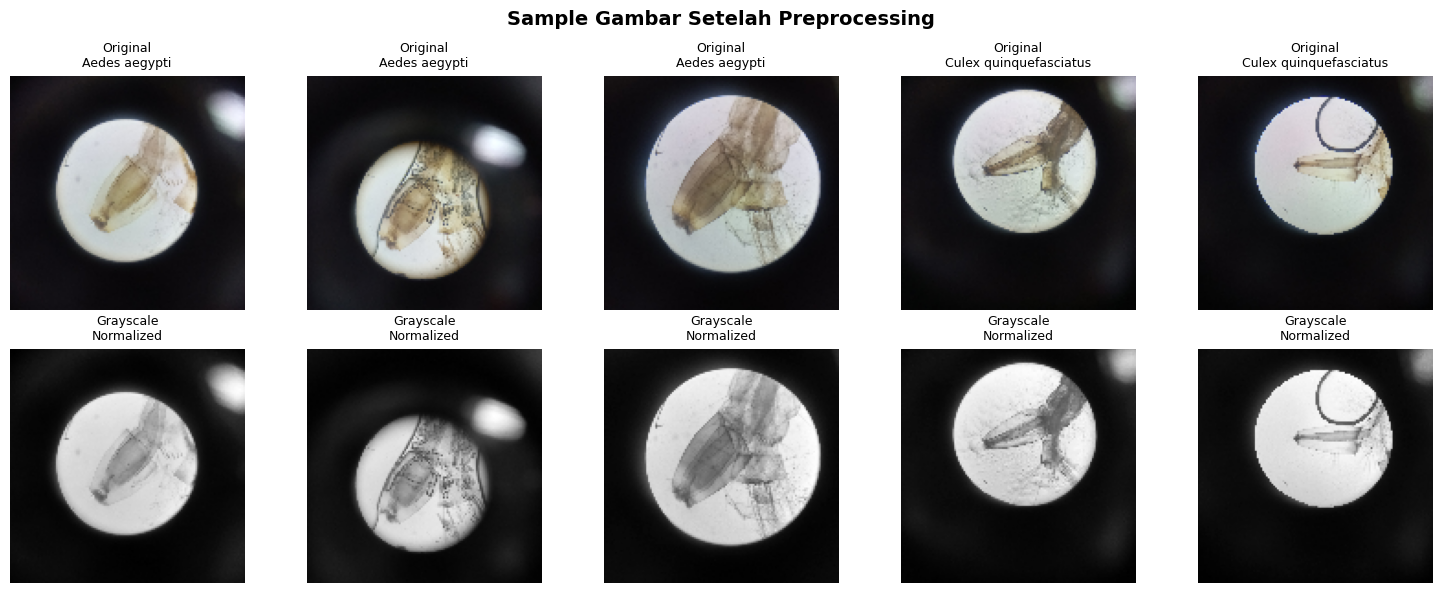

Shape gambar: (800, 128, 128), min=0.00, max=1.00


In [ ]:
aedes_idx = np.where(labels_raw =='Aedes aegypti')[0][:3] #sampel untuk validasi
culex_idx = np.where(labels_raw =='Culex quinquefasciatus')[0][:2]
sample_idx = np.concatenate([aedes_idx, culex_idx])

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Sample Gambar Setelah Preprocessing", fontsize=14, fontweight='bold')

for col, i in enumerate(sample_idx):
    axes[0, col].imshow(cv2.cvtColor(images_raw[i], cv2.COLOR_BGR2RGB)) #gambar asli di baris atas
    axes[0, col].set_title(f"Original\n{labels_raw[i]}", fontsize=9)
    axes[0, col].axis('off')
    axes[1, col].imshow(images_gray[i], cmap='gray') #hasil preprocessing di baris bawah
    axes[1, col].set_title(f"Grayscale\nNormalized", fontsize=9)
    axes[1, col].axis('off')

plt.tight_layout()
plt.show()
print(f"Shape gambar: {images_gray.shape}, min={images_gray.min():.2f}, max={images_gray.max():.2f}")

Setiap gambar di-resize ke 128×128 piksel dan dikumpulkan bersama labelnya. Total ada 800 citra dengan distribusi seimbang dengan 400 citra per spesies.

Gambar dikonversi ke grayscale bertujuan menyederhanakan representasi citra sekaligus mempertahankan informasi struktur penting, sedangkan normalisasi nilai piksel ke rentang [0,1] menghilangkan perbedaan skala intensitas akibat variasi kondisi pencahayaan mikroskop. Visualisasinya menampilkan perbandingan gambar sebelum dan sesudah preprocessing dari masing-masing spesies.

# Split Data

Data dibagi menjadi 80% training dan 20% testing menggunakan stratified split, pemisahan ini sengaja dilakukan sebelum augmentasi supaya tidak terjadi data leakage di mana variasi dari gambar yang sama tidak bocor ke data testing.

Hasilnya adalah 640 citra untuk training dan 160 citra untuk testing, masing-masing dengan distribusi 50:50 antar kelas.

In [ ]:
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(images_gray, labels_raw, test_size=0.2, random_state=SEED, stratify=labels_raw) #stratify supaya proporsi kelas tetap terjaga di train dan test

In [ ]:
print(f"Train: {len(X_train_raw)} gambar {dict(Counter(y_train_raw))}")
print(f"Test: {len(X_test_raw)} gambar {dict(Counter(y_test_raw))}")

Train: 640 gambar {np.str_('Aedes aegypti'): 320, np.str_('Culex quinquefasciatus'): 320}
Test: 160 gambar {np.str_('Culex quinquefasciatus'): 80, np.str_('Aedes aegypti'): 80}


# Augmentasi

Setiap gambar training diperbanyak menjadi 8 versi: original, flip horizontal, flip vertikal, rotasi 90°/180°/270°, penambahan Gaussian noise (σ=0.02), dan peningkatan brightness (×1.2). Tujuannya untuk menambah variasi data tanpa perlu mengumpulkan citra baru, sehingga meningkatkan kemampuan generalisasi model.

Hasilnya data training naik dari 640 jadi 5.120 citra, data testing tetap menggunakan citra asli tanpa augmentasi agar evaluasi model tetap objektif.

In [ ]:
def augment_image(image_gray_normalized):
    augmented = []
    img = image_gray_normalized.copy()
    augmented.append(img) #original
    augmented.append(np.fliplr(img)) #flip horizontal
    augmented.append(np.flipud(img)) #flip vertikal
    augmented.append(np.rot90(img, 1)) #rotasi 90°
    augmented.append(np.rot90(img, 2)) #rotasi 180°
    augmented.append(np.rot90(img, 3)) #rotasi 270°
    noise = np.random.normal(0, 0.02, img.shape) #gaussian Noise
    noisy = np.clip(img + noise, 0, 1)
    augmented.append(noisy)
    bright = np.clip(img * 1.2, 0, 1) #brightness
    augmented.append(bright)

    return augmented

In [ ]:
def augment_dataset(images_gray, labels):
    np.random.seed(SEED)
    aug_images, aug_labels = [], []
    print(f"Distribusi sebelum augmentasi: {dict(Counter(labels))}")
    for img, lbl in zip(images_gray, labels):
        for aug in augment_image(img): #tiap gambar menghasilkan 8 versi
            aug_images.append(aug)
            aug_labels.append(lbl)
    aug_images = np.array(aug_images)
    aug_labels = np.array(aug_labels)
    print(f"Distribusi setelah augmentasi: {dict(Counter(aug_labels))}")
    print(f"Total gambar setelah augmentasi: {len(aug_images)}")

    return aug_images, aug_labels

In [ ]:
np.random.seed(SEED)
X_train_aug, y_train_aug = augment_dataset(X_train_raw, y_train_raw) #augmentasi hanya di data train, data test menggunakan yang original setelah preprocessing

Distribusi sebelum augmentasi: {np.str_('Aedes aegypti'): 320, np.str_('Culex quinquefasciatus'): 320}
Distribusi setelah augmentasi: {np.str_('Aedes aegypti'): 2560, np.str_('Culex quinquefasciatus'): 2560}
Total gambar setelah augmentasi: 5120


In [ ]:
X_test_final = X_test_raw
y_test_final = y_test_raw

In [ ]:
print(f"Train (setelah augmentasi): {len(X_train_aug)}")
print(f"Test (data asli bersih): {len(X_test_final)}")

Train (setelah augmentasi): 5120
Test (data asli bersih): 160


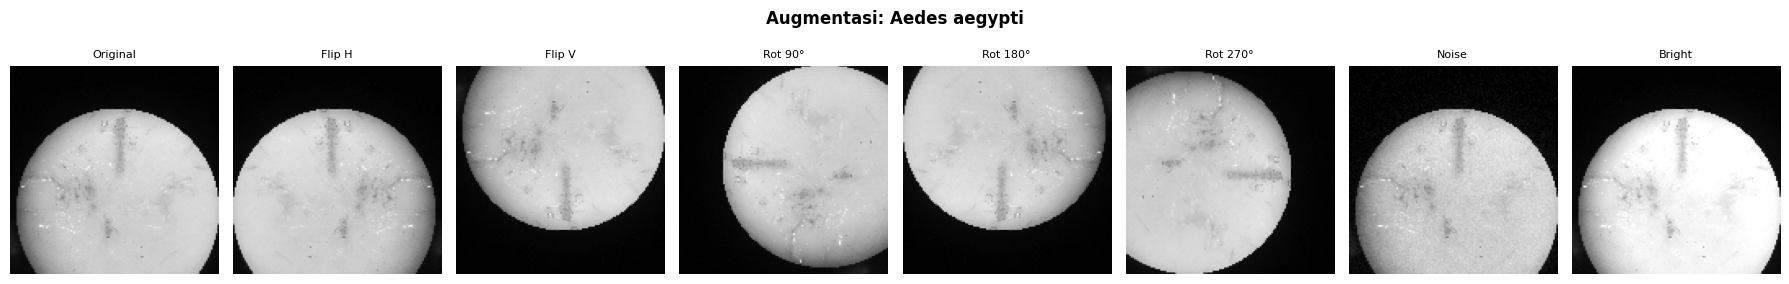

In [ ]:
#contoh visualisasi semua jenis augmentasi dari satu gambar
sample_aug = augment_image(X_train_raw[0])
fig, axes = plt.subplots(1, len(sample_aug), figsize=(18, 3))
aug_names = ['Original', 'Flip H', 'Flip V', 'Rot 90°', 'Rot 180°', 'Rot 270°', 'Noise', 'Bright']
for ax, aug_img, name in zip(axes, sample_aug, aug_names):
    ax.imshow(aug_img, cmap='gray')
    ax.set_title(name, fontsize=8)
    ax.axis('off')
plt.suptitle(f"Augmentasi: {y_train_raw[0]}", fontweight='bold')
plt.tight_layout()
plt.show()

# Exploratory Data Analysis

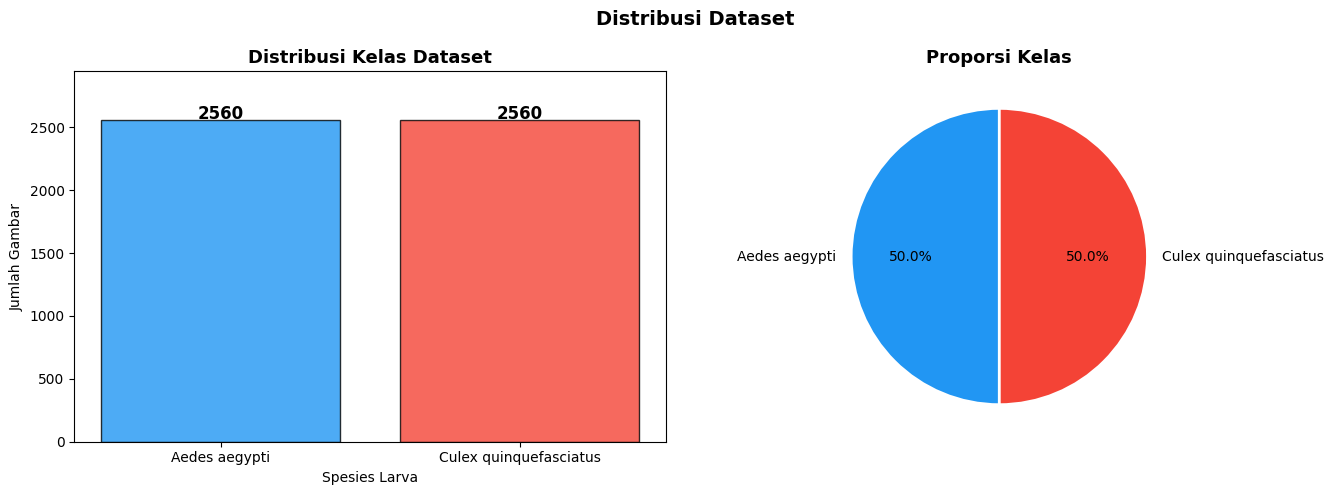

In [ ]:
class_counts = Counter(y_train_aug) #hitung jumlah sampel per kelas setelah augmentasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#bar chart distribusi kelas
axes[0].bar(class_counts.keys(), class_counts.values(), color=['#2196F3', '#F44336'], edgecolor='black', alpha=0.8)
for i, (cls, cnt) in enumerate(class_counts.items()):
    axes[0].text(i, cnt + 5, str(cnt), ha='center', fontweight='bold', fontsize=12)
axes[0].set_title('Distribusi Kelas Dataset', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Spesies Larva')
axes[0].set_ylabel('Jumlah Gambar')
axes[0].set_ylim(0, max(class_counts.values()) * 1.15)

#pie chart proporsi kelas
axes[1].pie(class_counts.values(), labels=class_counts.keys(), autopct='%1.1f%%', colors=['#2196F3', '#F44336'], startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporsi Kelas', fontweight='bold', fontsize=13)

plt.suptitle('Distribusi Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Bar chart dan pie chart menunjukkan distribusi kedua kelas setelah augmentasi seimbang,yaitu 2.560 citra per kelas atau 50% masing-masing. Kondisi ini memastikan model tidak akan bias ke salah satu spesies saja selama training.


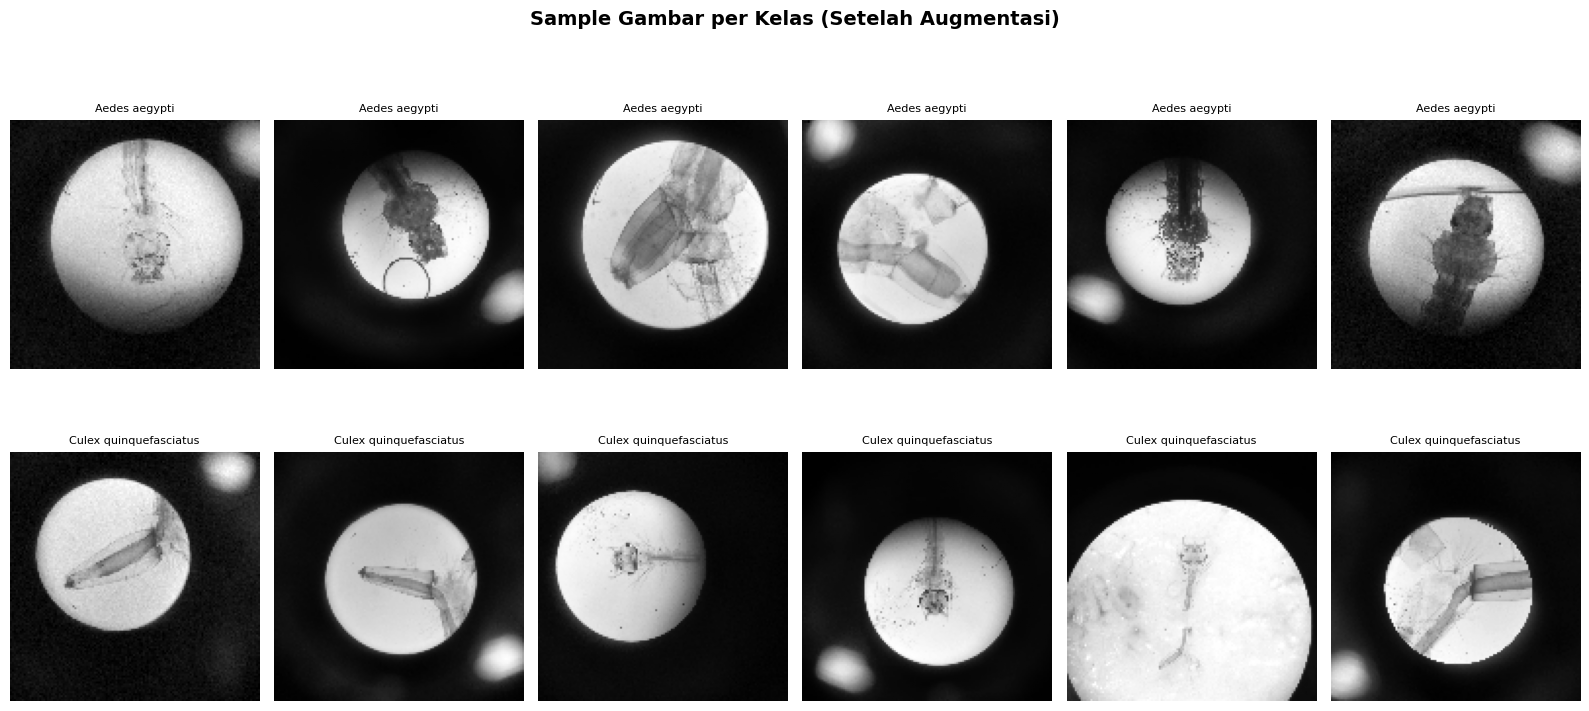

In [ ]:
#sample gambar per kelas dari data train augmented
fig, axes = plt.subplots(len(class_names), 6, figsize=(16, 4 * len(class_names)))
fig.suptitle('Sample Gambar per Kelas (Setelah Augmentasi)', fontsize=14, fontweight='bold')
for row, cls in enumerate(class_names):
    cls_indices = np.where(y_train_aug == cls)[0]
    sample_indices = np.random.choice(cls_indices, min(6, len(cls_indices)), replace=False)
    for col, idx in enumerate(sample_indices):
        ax = axes[row, col] if len(class_names) > 1 else axes[col]
        ax.imshow(X_train_aug[idx], cmap='gray')
        ax.set_title(cls, fontsize=8)
        ax.axis('off')
    for col in range(len(sample_indices), 6): #mengosongkan kolom  sisa
        ax = axes[row, col] if len(class_names) > 1 else axes[col]
        ax.axis('off')
plt.tight_layout()
plt.show()

Statistik Intensitas Pixel per Kelas
Aedes aegypti: mean=0.320, std=0.098
Culex quinquefasciatus: mean=0.330, std=0.106


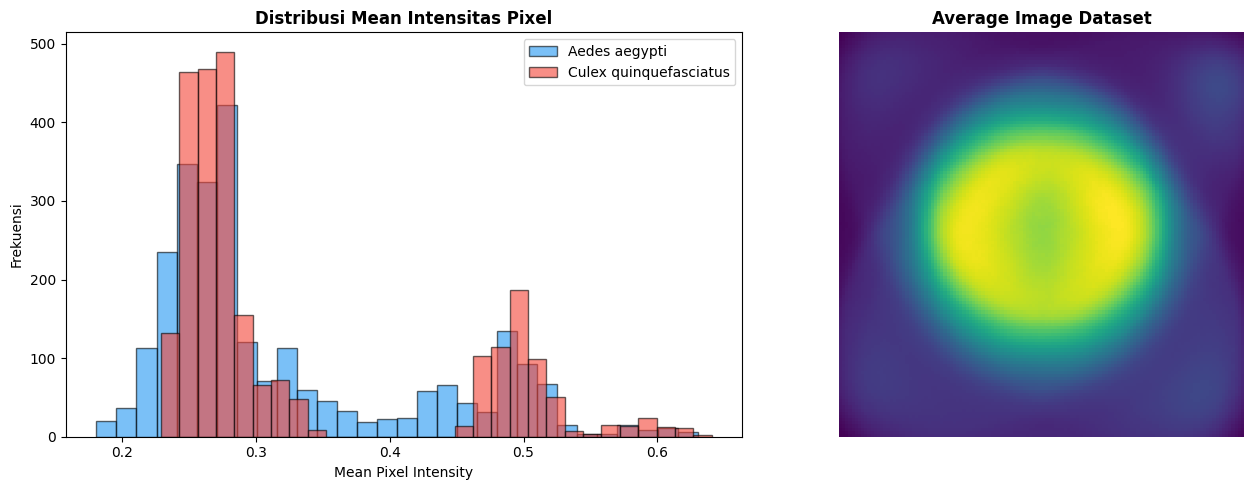

In [ ]:
print("Statistik Intensitas Pixel per Kelas")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#2196F3', '#F44336']

#histogram distribusi mean intensitas pixel per kelas
for i, cls in enumerate(class_names):
    cls_images = X_train_aug[y_train_aug == cls]
    pixel_means = cls_images.mean(axis=(1, 2))
    axes[0].hist(pixel_means, bins=30, alpha=0.6, label=cls, color=colors[i], edgecolor='black')
    print(f"{cls}: mean={pixel_means.mean():.3f}, std={pixel_means.std():.3f}")

axes[0].set_title('Distribusi Mean Intensitas Pixel', fontweight='bold')
axes[0].set_xlabel('Mean Pixel Intensity')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()

#average image
avg_img = X_train_aug.mean(axis=0)
axes[1].imshow(avg_img)
axes[1].set_title('Average Image Dataset', fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

Rata-rata intensitas piksel kedua spesies sangat mirip, Aedes 0,320 dan Culex 0,330. Karena hampir tidak ada perbedaan, informasi piksel saja tidak cukup untuk membedakan keduanya, maka dari itu diperlukan adanya ekstraksi fitur GLCM.

Average Image menampilkan struktur berbentuk lingkaran terang di tengah yang memudar ke pinggir, mengindikasikan bahwa objek larva secara konsisten terpusat pada area pandang mikroskop dan variasi antar citra lebih disebabkan perbedaan morfologi spesies daripada kondisi pengambilan gambar.



# GLCM

Dari tiap gambar diekstrak 48 fitur tekstur menggunakan GLCM dengan kombinasi 2 jarak, 4 sudut, dan 6 fitur statistik yaitu contrast, dissimilarity, homogeneity, energy, correlation, dan ASM. Proses ini dijalankan terpisah untuk data training (5.120 citra) dan testing (160 citra). Kombinasi jarak 1 dan 3 bertujuan menangkap tekstur halus maupun kasar, sedangkan 4 sudut memastikan seluruh orientasi tekstur tercakup, fitur-fitur inilah yang nantinya akan menjadi input model KNN dan SVM.

In [ ]:
def extract_glcm_features(image_normalized):
    img_uint8 = img_as_ubyte(image_normalized) #convert ke uint8 [0, 255] karena graycomatrix butuh format seperti ini
    angles = [0, np.pi/4, np.pi/2, 3*np.pi/4] #hitung GLCM menggunakan 2 jarak dan 4 sudut, sehingga ada 8 kombinasi per fitur
    glcm = graycomatrix(img_uint8, distances=[1, 3], angles=angles, levels=256, symmetric=True, normed=True)

    features = []
    props = ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation', 'ASM']
    for prop in props:
        feat = graycoprops(glcm, prop)  #shape (n_distances, n_angles)
        features.extend(feat.flatten().tolist()) #flatten semua kombinasi jarak dan sudut

    return np.array(features)

In [ ]:
def extract_all_features(images, labels, verbose=True):
    feature_list = []
    n = len(images)
    for i, img in enumerate(images):
        feat = extract_glcm_features(img)
        feature_list.append(feat)
        if verbose and (i+1) % 100 == 0:
            print(f"Progress: {i+1}/{n} gambar sedang diproses")

    X = np.array(feature_list)
    y = np.array(labels)
    print(f"Ekstraksi selesai!")
    print(f"shape Feature Vector: {X.shape} ({X.shape[0]} sampel, {X.shape[1]} fitur)")
    return X, y

In [ ]:
print("Mengekstraksi fitur GLCM train")
X_feat_train, y_feat_train = extract_all_features(X_train_aug, y_train_aug)

Mengekstraksi fitur GLCM train
Progress: 100/5120 gambar sedang diproses
Progress: 200/5120 gambar sedang diproses
Progress: 300/5120 gambar sedang diproses
Progress: 400/5120 gambar sedang diproses
Progress: 500/5120 gambar sedang diproses
Progress: 600/5120 gambar sedang diproses
Progress: 700/5120 gambar sedang diproses
Progress: 800/5120 gambar sedang diproses
Progress: 900/5120 gambar sedang diproses
Progress: 1000/5120 gambar sedang diproses
Progress: 1100/5120 gambar sedang diproses
Progress: 1200/5120 gambar sedang diproses
Progress: 1300/5120 gambar sedang diproses
Progress: 1400/5120 gambar sedang diproses
Progress: 1500/5120 gambar sedang diproses
Progress: 1600/5120 gambar sedang diproses
Progress: 1700/5120 gambar sedang diproses
Progress: 1800/5120 gambar sedang diproses
Progress: 1900/5120 gambar sedang diproses
Progress: 2000/5120 gambar sedang diproses
Progress: 2100/5120 gambar sedang diproses
Progress: 2200/5120 gambar sedang diproses
Progress: 2300/5120 gambar sedan

In [ ]:
print("Mengekstraksi fitur GLCM test")
X_feat_test, y_feat_test = extract_all_features(X_test_final, y_test_final)

Mengekstraksi fitur GLCM test
Progress: 100/160 gambar sedang diproses
Ekstraksi selesai!
shape Feature Vector: (160, 48) (160 sampel, 48 fitur)


In [ ]:
#kombinasi fitur tekstur, jarak dan sudut
props = ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation', 'ASM']
distances = [1, 3]
angles_deg = [0, 45, 90, 135]
feature_names = [f"{p}_d{d}_a{a}" for p in props for d in distances for a in angles_deg]
print(f"Jumlah fitur: {len(feature_names)}")

Jumlah fitur: 48


In [ ]:
feature_df = pd.DataFrame(X_feat_train, columns=feature_names)
feature_df['label'] = y_feat_train
print("Statistik fitur data train")
print(feature_df.describe().round(4))

Statistik fitur data train
       contrast_d1_a0  contrast_d1_a45  contrast_d1_a90  contrast_d1_a135  \
count       5120.0000        5120.0000        5120.0000         5120.0000   
mean         220.8317         333.8075         216.4537          333.4738   
std           56.2843          76.8091          56.0789           74.9958   
min           66.3323         106.9779          66.3323          106.9779   
25%          181.9767         285.2822         178.2226          287.2836   
50%          214.4586         326.0800         209.9996          326.6276   
75%          254.2431         374.3864         248.1120          373.1479   
max          481.8527         861.2134         584.2348          693.8049   

       contrast_d3_a0  contrast_d3_a45  contrast_d3_a90  contrast_d3_a135  \
count       5120.0000        5120.0000        5120.0000         5120.0000   
mean         820.6191         769.7687         814.8716          768.8820   
std          168.5926         156.7653         1

In [ ]:
#simpan fitur GLCM train ke CSV
feature_df.to_csv('glcm_features_train.csv', index=False)
print(f"Disimpan: glcm_features_train.csv ({feature_df.shape[0]} baris, {feature_df.shape[1]} kolom)")

#simpan fitur GLCM test ke CSV
feature_df_test = pd.DataFrame(X_feat_test, columns=feature_names)
feature_df_test['label'] = y_feat_test
feature_df_test.to_csv('glcm_features_test.csv', index=False)
print(f"Disimpan: glcm_features_test.csv ({feature_df_test.shape[0]} baris, {feature_df_test.shape[1]} kolom)")

Disimpan: glcm_features_train.csv (5120 baris, 49 kolom)
Disimpan: glcm_features_test.csv (160 baris, 49 kolom)


In [ ]:
le = LabelEncoder() #convert label string ke integer untuk keperluan model sklearn
le.fit(y_feat_train)
y_train_enc = le.transform(y_feat_train)
y_test_enc = le.transform(y_feat_test)
print(f"Label encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}")

Label encoding: {np.str_('Aedes aegypti'): np.int64(0), np.str_('Culex quinquefasciatus'): np.int64(1)}


Label dikonversi menjadi angka, Aedes = 0 dan Culex = 1. Visualisasi distribusi 6 fitur menunjukkan beberapa fitur seperti ASM dan energy punya pola yang cukup berbeda antar spesies, sedangkan correlation hampir tumpang tindih sehingga paling sulit dipakai sebagai pembeda.

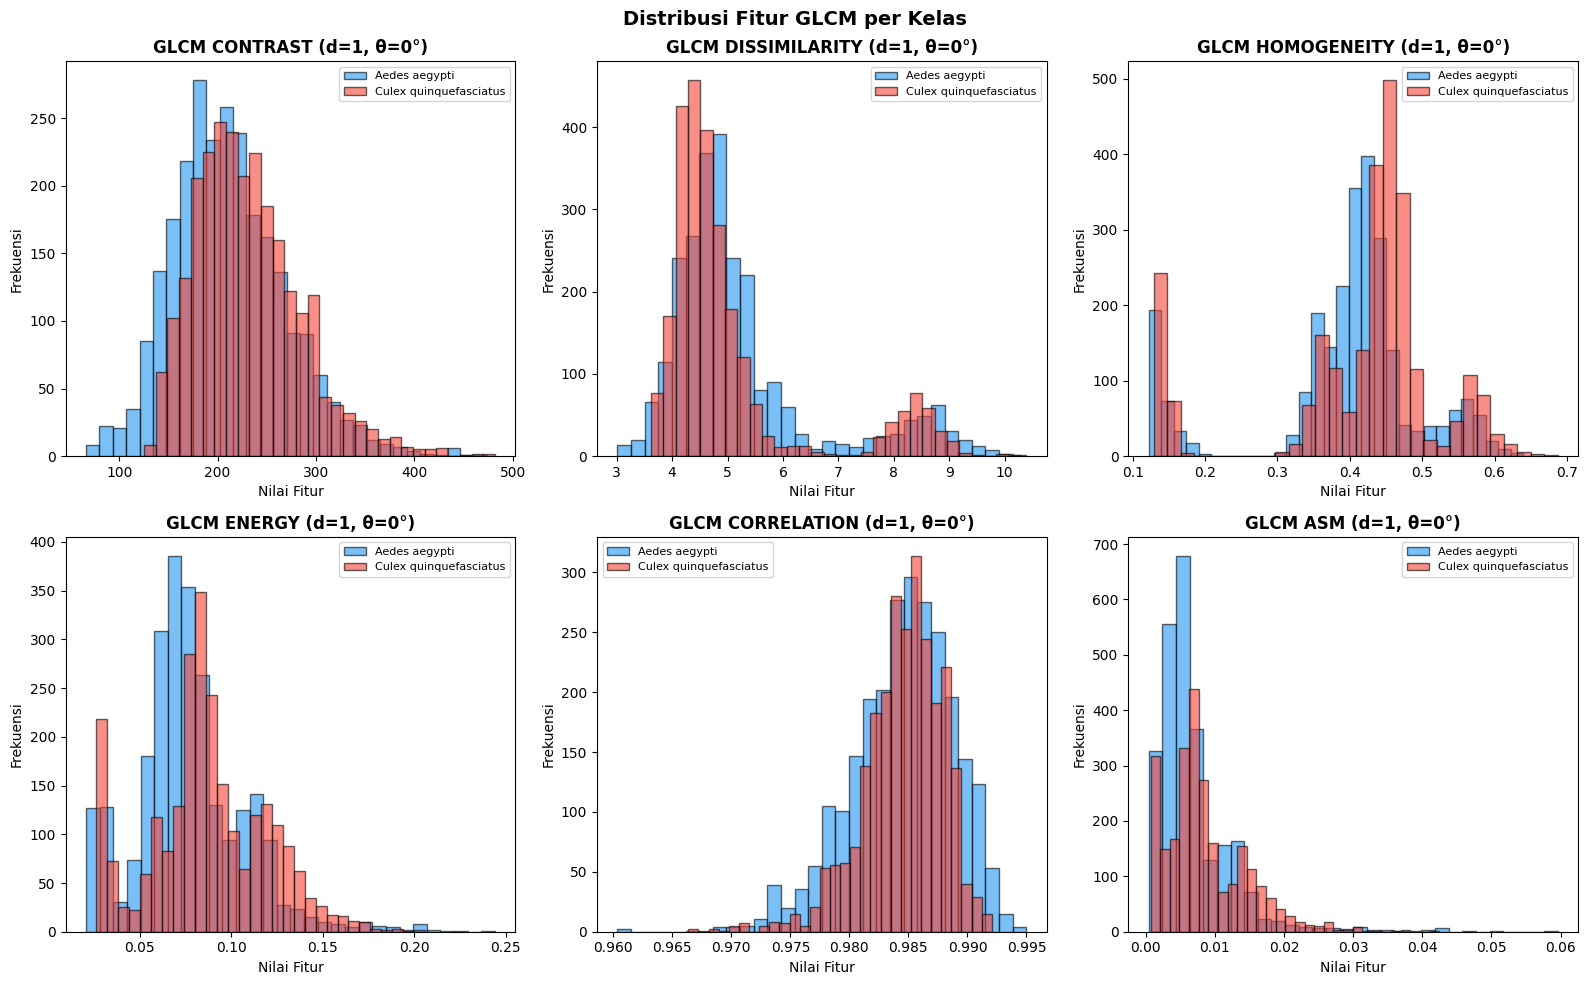

In [ ]:
#distribusi fitur GLCM per kelas
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
main_props = ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation', 'ASM']
colors = ['#2196F3', '#F44336']

for ax, prop in zip(axes, main_props):
    col = f"{prop}_d1_a0"  #ambil d=1, angle=0° sebagai representasi
    for i, cls in enumerate(class_names):
        vals = feature_df[feature_df['label'] == cls][col].values
        ax.hist(vals, bins=30, alpha=0.6, label=cls, color=colors[i], edgecolor='black')
    ax.set_title(f'GLCM {prop.upper()} (d=1, θ=0°)', fontweight='bold')
    ax.set_xlabel('Nilai Fitur')
    ax.set_ylabel('Frekuensi')
    ax.legend(fontsize=8)

plt.suptitle('Distribusi Fitur GLCM per Kelas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Pada fitur contrast, Aedes Aegypti memiliki persebaran yang lebih luas dibandingkan Culex Quinquefasciatus, mengindikasikan variasi intensitas antar piksel yang lebih beragam. Pada dissimilarity, kedua kelas menunjukkan pola bimodal yang mengindikasikan adanya dua kelompok karakteristik tekstur, kemungkinan dipengaruhi variasi anatomi larva. Pada homogeneity, nilai Culex yang lebih tinggi memvalidasi bahwa teksturnya lebih seragam dibandingkan Aedes. Fitur energy menunjukkan Aedes menumpuk pada nilai yang sangat rendah, mencerminkan kompleksitas tekstur yang sedikit lebih tinggi. Fitur correlation menunjukkan distribusi yang tumpang tindih pada kedua kelas sehingga menjadi fitur yang paling sulit digunakan sebagai pembeda. Terakhir, fitur ASM menunjukkan perbedaan tinggi puncak yang sangat mencolok meskipun kedua kelas berada pada rentang nilai yang sama. Secara umum, fitur GLCM mampu menunjukkan pola pembeda antar spesies yang tidak tampak dari informasi intensitas piksel saja.

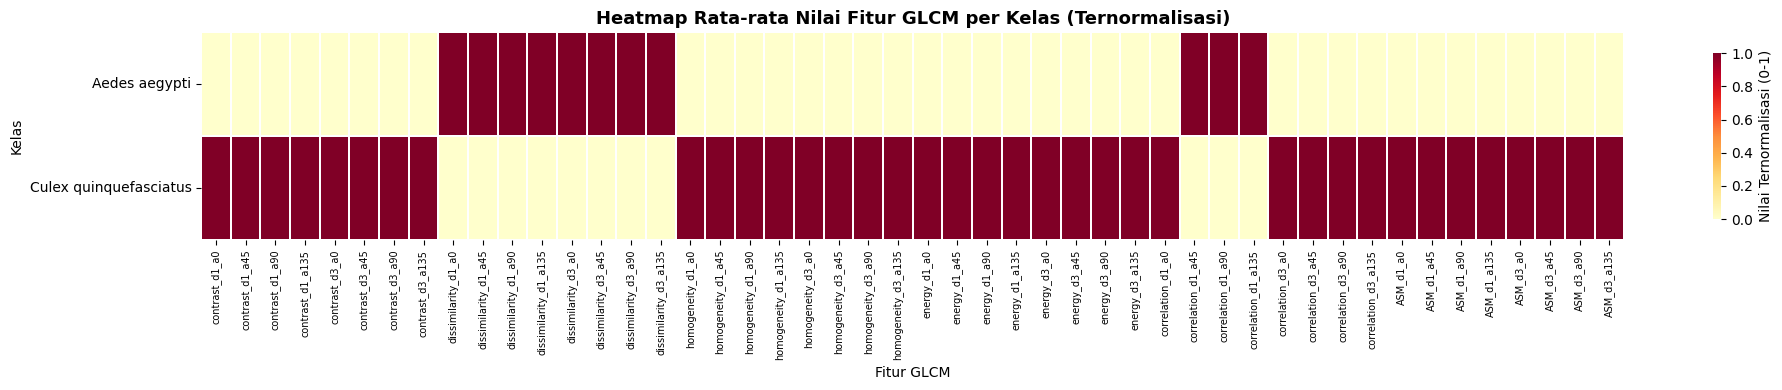

In [ ]:
#heatmap rata-rata nilai fitur per kelas
mean_per_class = feature_df.groupby('label')[feature_names].mean()

scaler_viz = MinMaxScaler()
mean_normalized = pd.DataFrame(scaler_viz.fit_transform(mean_per_class), index=mean_per_class.index, columns=mean_per_class.columns) #normalisasi per baris supaya tiap kelas punya skala sendiri

plt.figure(figsize=(20, 4))
sns.heatmap(mean_normalized, cmap='YlOrRd', annot=False, linewidths=0.3, cbar_kws={"shrink": 0.8, "label": "Nilai Ternormalisasi (0-1)"}, yticklabels=mean_normalized.index, vmin=0, vmax=1)
plt.title('Heatmap Rata-rata Nilai Fitur GLCM per Kelas (Ternormalisasi)', fontweight='bold', fontsize=13)
plt.xlabel('Fitur GLCM')
plt.ylabel('Kelas')
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Culex Quinquefasciatus menunjukkan nilai yang lebih tinggi pada fitur contrast, homogeneity, energy, dan ASM, yang menandakan tekstur dari kelas ini cenderung seragam dan teratur. Aedes Aegypti menunjukkan nilai korelasi yang lebih tinggi pada fitur dissimilarity dan correlation, sehingga bisa disimpulkan bahwa kelas ini memiliki variasi tekstur yang lebih besar. Perbedaan ini mengkonfirmasi bahwa fitur GLCM mampu menangkap perbedaan karakteristik tekstur antar spesies, sehingga mendukung penggunaanya sebagai input pada model klasifikasi.

In [ ]:
def detect_outliers_iqr(X, feature_names): #deteksi outlier menggunakan metode IQR
    outlier_counts = {}
    total_outlier_mask = np.zeros(X.shape[0], dtype=bool)

    for i, fname in enumerate(feature_names):
        col = X[:, i]
        Q1 = np.percentile(col, 25)
        Q3 = np.percentile(col, 75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR #batas bawah
        upper = Q3 + 1.5 * IQR #batas atas
        mask = (col < lower) | (col > upper) #tandai yang diluar batas
        outlier_counts[fname] = int(mask.sum())
        total_outlier_mask |= mask #gabungkan semua fitur

    return outlier_counts, total_outlier_mask

outlier_counts, total_outlier_mask = detect_outliers_iqr(X_feat_train, feature_names)

In [ ]:
outlier_df = pd.DataFrame({
    'Fitur': list(outlier_counts.keys()),
    'Jumlah Outlier': list(outlier_counts.values()),
    'Persentase (%)': [v / len(X_feat_train) * 100 for v in outlier_counts.values()]
}).sort_values('Jumlah Outlier', ascending=False) #ringkasan hasil deteksi outlier

print(outlier_df.to_string(index=False))
print(f"\nTotal sampel train          : {len(X_feat_train)}")
print(f"Sampel dengan outlier ≥1    : {total_outlier_mask.sum()}")
print(f"Persentase sampel outlier   : {total_outlier_mask.sum()/len(X_feat_train)*100:.2f}%")

                Fitur  Jumlah Outlier  Persentase (%)
    homogeneity_d1_a0             710       13.867188
   homogeneity_d1_a90             688       13.437500
    homogeneity_d3_a0             687       13.417969
  homogeneity_d1_a135             686       13.398437
   homogeneity_d1_a45             678       13.242188
   homogeneity_d3_a45             673       13.144531
  homogeneity_d3_a135             672       13.125000
 dissimilarity_d1_a90             668       13.046875
   homogeneity_d3_a90             666       13.007812
  dissimilarity_d1_a0             666       13.007812
dissimilarity_d1_a135             641       12.519531
 dissimilarity_d1_a45             636       12.421875
      contrast_d3_a45             383        7.480469
      contrast_d3_a90             352        6.875000
     contrast_d3_a135             288        5.625000
            ASM_d3_a0             272        5.312500
       contrast_d3_a0             267        5.214844
          ASM_d3_a135       

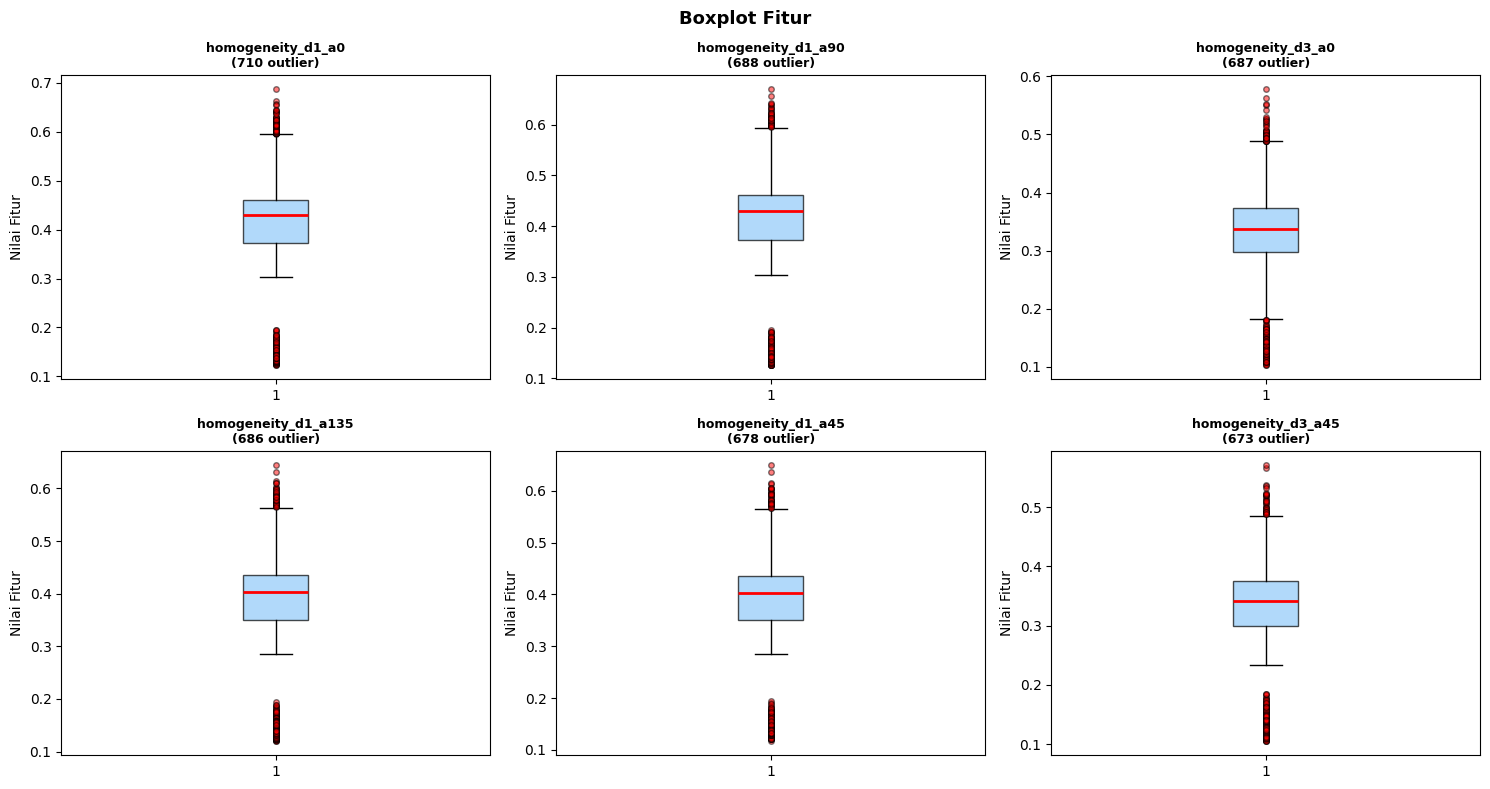

In [ ]:
#boxplot fitur dengan outlier terbanyak
top_outlier_feats = outlier_df.head(6)['Fitur'].tolist()
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for ax, feat in zip(axes, top_outlier_feats):
    idx = feature_names.index(feat)
    ax.boxplot(X_feat_train[:, idx], patch_artist=True, boxprops=dict(facecolor='#90CAF9', alpha=0.7), medianprops=dict(color='red', linewidth=2), flierprops=dict(marker='o', markerfacecolor='red', markersize=4, alpha=0.5))
    ax.set_title(f'{feat}\n({outlier_counts[feat]} outlier)', fontsize=9, fontweight='bold')
    ax.set_ylabel('Nilai Fitur')
plt.suptitle('Boxplot Fitur', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

Metode IQR menemukan outlier terbanyak ada di fitur homogeneity, dan secara keseluruhan 30,45% sampel training mengandung setidaknya satu outlier. Outlier tidak dihapus karena dianggap mencerminkan variasi wajar dari empat bagian anatomi larva yang berbeda (head, abdomen-8, siphon, full body).

# Normalisasi Fitur

In [ ]:
scaler = RobustScaler() #menggunakan median dan iqr sehingga lebih tahan outlier dibandingkan standardscaler

X_train_scaled = scaler.fit_transform(X_feat_train) #fit di train, transform di train
X_test_scaled  = scaler.transform(X_feat_test) #test hanya di transform

In [ ]:
print(f"X_train: {X_train_scaled.shape}")
print(f"X_test: {X_test_scaled.shape}")

X_train: (5120, 48)
X_test: (160, 48)


RobustScaler dipilih karena berbasis median dan IQR sehingga tidak mudah terpengaruh outlier, berbeda dengan StandardScaler yang berbasis mean dan lebih sensitif. Scaler hanya di-fit ke data training, lalu hasilnya dipakai untuk transform data training dan testing (penting untuk mencegah kebocoran informasi dari data uji ke proses normalisasi).

# K-Nearest Neighbors

In [ ]:
#mencari kombinasi hyperparameter terbaik lewat grid search dengan 5 fold cross validation
knn_params = {'n_neighbors': [3, 5, 7, 9, 11, 12, 13, 14, 15, 16, 17, 18, 19], 'metric': ['euclidean', 'manhattan', 'minkowski'], 'weights': ['uniform', 'distance']}
knn_grid = GridSearchCV(KNeighborsClassifier(), knn_params, cv=5, scoring='accuracy', n_jobs=-1, verbose=0)
knn_grid.fit(X_train_scaled, y_train_enc)
best_knn = knn_grid.best_estimator_
print(f"Best Parameters : {knn_grid.best_params_}")
print(f"Best CV Score : {knn_grid.best_score_:.4f}")

Best Parameters : {'metric': 'euclidean', 'n_neighbors': 14, 'weights': 'distance'}
Best CV Score : 0.8100


GridSearchCV dengan 5-fold cross-validation digunakan untuk mencari kombinasi terbaik dari nilai K, metrik jarak, dan bobot. Hasilnya parameter terbaik adalah K=14, jarak euclidean, bobot distance dengan CV Score 0,8100.

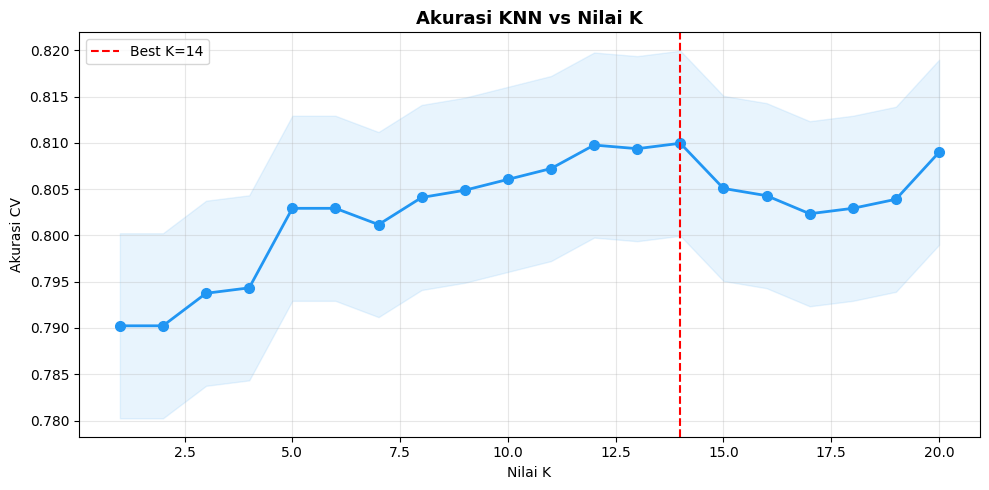

In [ ]:
#visualisasi pengaruh nilai K terhadap akurasi cross validation
k_range = range(1, 21)
k_scores = []
for k in k_range:
    knn_temp = KNeighborsClassifier(n_neighbors=k, metric=knn_grid.best_params_['metric'], weights=knn_grid.best_params_['weights'])
    scores = cross_val_score(knn_temp, X_train_scaled, y_train_enc, cv=5, scoring='accuracy')
    k_scores.append(scores.mean())

plt.figure(figsize=(10, 5))
plt.plot(k_range, k_scores, marker='o', color='#2196F3', linewidth=2, markersize=7)
plt.axvline(x=knn_grid.best_params_['n_neighbors'], color='red', linestyle='--', label=f"Best K={knn_grid.best_params_['n_neighbors']}")
plt.fill_between(k_range, [s - 0.01 for s in k_scores], [s + 0.01 for s in k_scores], alpha=0.1, color='#2196F3')
plt.title('Akurasi KNN vs Nilai K', fontweight='bold', fontsize=13)
plt.xlabel('Nilai K')
plt.ylabel('Akurasi CV')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Akurasi CV relatif stabil pada rentang 0,79–0,81 untuk seluruh nilai K, dengan puncak pada K=14 (0,8100). Pola grafik yang mendatar mengindikasikan model tidak terlalu sensitif terhadap perubahan nilai K, yang berarti fitur GLCM cukup stabil dalam mengukur kedekatan antar sampel.

In [ ]:
#prediksi dan perhitungan semua metrik evaluasi
y_pred_knn = best_knn.predict(X_test_scaled)
acc_knn = accuracy_score(y_test_enc, y_pred_knn)
prec_knn = precision_score(y_test_enc, y_pred_knn, average='weighted')
rec_knn = recall_score(y_test_enc, y_pred_knn, average='weighted')
f1_knn = f1_score(y_test_enc, y_pred_knn, average='weighted')
cm_knn = confusion_matrix(y_test_enc, y_pred_knn)

print(f"Accuracy: {acc_knn:.4f} ({acc_knn*100:.2f}%)")
print(f"Precision : {prec_knn:.4f}")
print(f"Recall : {rec_knn:.4f}")
print(f"F1-Score : {f1_knn:.4f}")
print(f"\n{classification_report(y_test_enc, y_pred_knn, target_names=le.classes_)}")

Accuracy: 0.8250 (82.50%)
Precision : 0.8423
Recall : 0.8250
F1-Score : 0.8228

                        precision    recall  f1-score   support

         Aedes aegypti       0.92      0.71      0.80        80
Culex quinquefasciatus       0.77      0.94      0.84        80

              accuracy                           0.82       160
             macro avg       0.84      0.82      0.82       160
          weighted avg       0.84      0.82      0.82       160



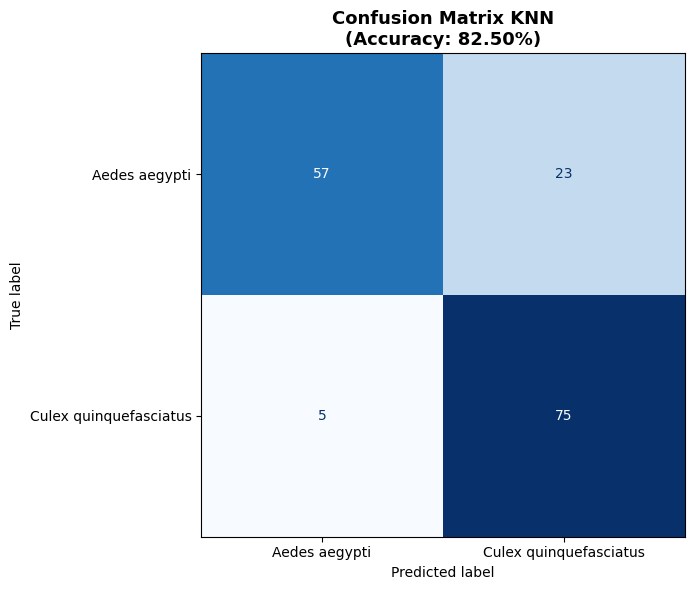

In [ ]:
#confusion matrix
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=le.classes_)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix KNN\n(Accuracy: {acc_knn*100:.2f}%)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
#export hasil prediksi ke CSV
results_df = pd.DataFrame({
    'True_Label': le.inverse_transform(y_test_enc),
    'Predicted_Label': le.inverse_transform(y_pred_knn),
    'Correct': y_test_enc == y_pred_knn
})
results_df.to_csv('hasil_prediksi_knn.csv', index=False)
print(results_df.head(10))

               True_Label         Predicted_Label  Correct
0  Culex quinquefasciatus  Culex quinquefasciatus     True
1           Aedes aegypti  Culex quinquefasciatus    False
2           Aedes aegypti           Aedes aegypti     True
3  Culex quinquefasciatus  Culex quinquefasciatus     True
4  Culex quinquefasciatus  Culex quinquefasciatus     True
5           Aedes aegypti           Aedes aegypti     True
6  Culex quinquefasciatus  Culex quinquefasciatus     True
7           Aedes aegypti  Culex quinquefasciatus    False
8           Aedes aegypti           Aedes aegypti     True
9  Culex quinquefasciatus  Culex quinquefasciatus     True


Model KNN menghasilkan akurasi 82,50% pada data testing, model lebih mudah mengenali Culex dengan recall 0,94, tapi cukup sering salah pada Aedes. Dari 80 citra Aedes, 23 di antaranya salah diklasifikasikan. Hal ini menunjukkan sebagian fitur GLCM Aedes masih mirip dengan Culex sehingga model kesulitan membedakannya.

# KNN K=19

Model KNN kedua dibangun menggunakan K=19 sebagai pembanding terhadap KNN terbaik hasil GridSearchCV, dengan metric dan weights mengikuti hasil tuning sebelumnya yaitu euclidean dan distance.

In [ ]:
#model knn dengan k=19 , berdasarkan analisis grafik akurasi vs K
knn_k19 = KNeighborsClassifier(n_neighbors=19, metric=knn_grid.best_params_['metric'], weights=knn_grid.best_params_['weights'])
knn_k19.fit(X_train_scaled, y_train_enc)

y_pred_knn19 = knn_k19.predict(X_test_scaled)
acc_knn19 = accuracy_score(y_test_enc, y_pred_knn19)
prec_knn19 = precision_score(y_test_enc, y_pred_knn19, average='weighted')
rec_knn19 = recall_score(y_test_enc, y_pred_knn19, average='weighted')
f1_knn19 = f1_score(y_test_enc, y_pred_knn19, average='weighted')
cm_knn19 = confusion_matrix(y_test_enc, y_pred_knn19)

print(f"KNN k=19 Accuracy: {acc_knn19:.4f} ({acc_knn19*100:.2f}%)")
print(f"KNN k=19 Precision: {prec_knn19:.4f}")
print(f"KNN k=19 Recall: {rec_knn19:.4f}")
print(f"KNN k=19 F1-Score: {f1_knn19:.4f}")
print(f"\n{classification_report(y_test_enc, y_pred_knn19, target_names=le.classes_)}")

KNN k=19 Accuracy: 0.8313 (83.12%)
KNN k=19 Precision: 0.8433
KNN k=19 Recall: 0.8313
KNN k=19 F1-Score: 0.8298

                        precision    recall  f1-score   support

         Aedes aegypti       0.91      0.74      0.81        80
Culex quinquefasciatus       0.78      0.93      0.85        80

              accuracy                           0.83       160
             macro avg       0.84      0.83      0.83       160
          weighted avg       0.84      0.83      0.83       160



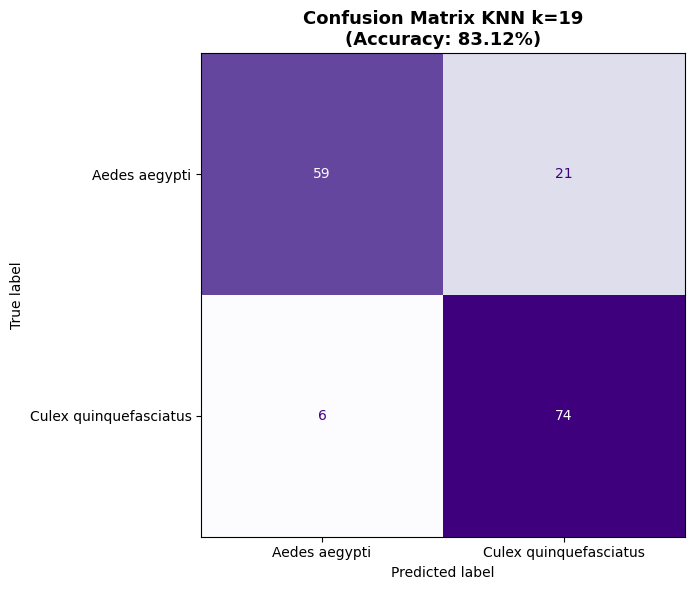

In [ ]:
#confusion matrix KNN k=19
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn19, display_labels=le.classes_)
disp.plot(ax=ax, cmap='Purples', colorbar=False)
ax.set_title(f'Confusion Matrix KNN k=19\n(Accuracy: {acc_knn19*100:.2f}%)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
#export hasil prediksi ke CSV
results_df = pd.DataFrame({
    'True_Label': le.inverse_transform(y_test_enc),
    'Predicted_Label': le.inverse_transform(y_pred_knn19),
    'Correct': y_test_enc == y_pred_knn19
})
results_df.to_csv('hasil_prediksi_knn19.csv', index=False)
print(results_df.head(10))

               True_Label         Predicted_Label  Correct
0  Culex quinquefasciatus  Culex quinquefasciatus     True
1           Aedes aegypti  Culex quinquefasciatus    False
2           Aedes aegypti           Aedes aegypti     True
3  Culex quinquefasciatus  Culex quinquefasciatus     True
4  Culex quinquefasciatus  Culex quinquefasciatus     True
5           Aedes aegypti           Aedes aegypti     True
6  Culex quinquefasciatus  Culex quinquefasciatus     True
7           Aedes aegypti  Culex quinquefasciatus    False
8           Aedes aegypti           Aedes aegypti     True
9  Culex quinquefasciatus  Culex quinquefasciatus     True


Model KNN K=19 menghasilkan akurasi 83,13% dengan precision 0,84, recall 0,83, dan F1-score 0,83. Pola performa antar kelas konsisten dengan model sebelumnya, di mana Culex Quinquefasciatus memiliki recall lebih tinggi (0,93) sementara Aedes Aegypti lebih unggul pada precision (0,91). Dari 80 citra Aedes, 21 sampel salah diklasifikasikan lebih sedikit dibanding KNN Best (23 salah),mdengan akurasi keseluruhan yang sedikit lebih baik.

# SVM

In [ ]:
#untuk mencari kombinasi C, kernel, dan gamma terbaik
svm_params = {'C': [0.1, 1, 10, 100], 'kernel': ['rbf', 'linear', 'poly'], 'gamma': ['scale', 'auto']}
svm_grid = GridSearchCV( SVC(probability=True, random_state=SEED), svm_params, cv=5, scoring='accuracy', n_jobs=-1, verbose=0)
svm_grid.fit(X_train_scaled, y_train_enc)
best_svm = svm_grid.best_estimator_
print(f"Best Parameters: {svm_grid.best_params_}")
print(f"Best CV Score: {svm_grid.best_score_:.4f}")

Best Parameters: {'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV Score: 0.8652


GridSearchCV dengan 5-fold cross-validation mencari kombinasi terbaik dari C, jenis kernel, dan gamma. Hasilnya parameter terbaik adalah C=100, kernel RBF, gamma=scale dengan CV Score 0,8652 lebih tinggi dari KNN.


In [ ]:
#prediksi dam evaluasi
y_pred_svm = best_svm.predict(X_test_scaled)
acc_svm = accuracy_score(y_test_enc, y_pred_svm)
prec_svm = precision_score(y_test_enc, y_pred_svm, average='weighted')
rec_svm = recall_score(y_test_enc, y_pred_svm, average='weighted')
f1_svm = f1_score(y_test_enc, y_pred_svm, average='weighted')
cm_svm = confusion_matrix(y_test_enc, y_pred_svm)

print(f"Accuracy: {acc_svm:.4f} ({acc_svm*100:.2f}%)")
print(f"Precision: {prec_svm:.4f}")
print(f"Recall: {rec_svm:.4f}")
print(f"F1-Score: {f1_svm:.4f}")
print(f"\n{classification_report(y_test_enc, y_pred_svm, target_names=le.classes_)}")

Accuracy: 0.9062 (90.62%)
Precision: 0.9078
Recall: 0.9062
F1-Score: 0.9062

                        precision    recall  f1-score   support

         Aedes aegypti       0.93      0.88      0.90        80
Culex quinquefasciatus       0.88      0.94      0.91        80

              accuracy                           0.91       160
             macro avg       0.91      0.91      0.91       160
          weighted avg       0.91      0.91      0.91       160



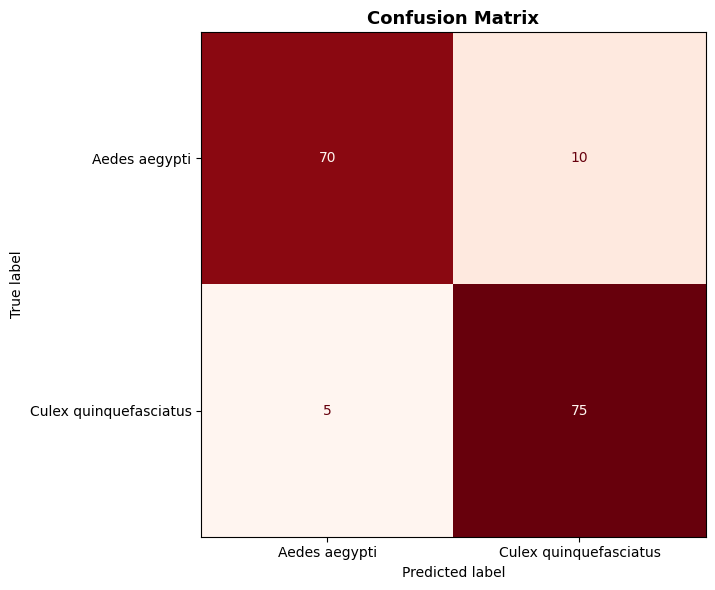

In [ ]:
#confusion matrix
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=le.classes_)
disp.plot(ax=ax, cmap='Reds', colorbar=False)
ax.set_title(f'Confusion Matrix', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
#export hasil prediksi ke CSV
results_svm_df = pd.DataFrame({
    'True_Label': le.inverse_transform(y_test_enc),
    'Predicted_Label': le.inverse_transform(y_pred_svm),
    'Correct': y_test_enc == y_pred_svm
})
results_svm_df.to_csv('hasil_prediksi_svm.csv', index=False)

Model SVM menghasilkan akurasi 90,62% dengan precision, recall, dan F1-score masing-masing 0,91 yang berarti cukup konsisten di kedua kelas. Kesalahan klasifikasi jauh lebih sedikit dibanding KNN, hanya 10 dari 80 citra Aedes yang salah. Hal ini menunjukkan SVM lebih baik dalam mengenali pola tekstur GLCM yang membedakan kedua spesies.

# Random Forest

In [ ]:
#grid search random forest
rf_params = {'n_estimators': [100, 200], 'max_depth': [None, 10, 20], 'min_samples_split': [2, 5], 'max_features': ['sqrt', 'log2']}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=SEED), rf_params, cv=5, scoring='accuracy', n_jobs=-1, verbose=0)
rf_grid.fit(X_train_scaled, y_train_enc)
best_rf = rf_grid.best_estimator_
print(f"Best Parameters: {rf_grid.best_params_}")
print(f"Best CV Score: {rf_grid.best_score_:.4f}")

Best Parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 100}
Best CV Score: 0.8068


GridSearchCV dengan 5-fold cross-validation mencari kombinasi terbaik dari n_estimators, max_depth, min_samples_split, dan max_features. Hasilnya parameter terbaik adalah n_estimators=100, max_depth=20, min_samples_split=5, max_features=sqrt dengan CV Score 0,8068.

In [ ]:
#prediksi dan evaluasi random forest
y_pred_rf = best_rf.predict(X_test_scaled)
acc_rf = accuracy_score(y_test_enc, y_pred_rf)
prec_rf = precision_score(y_test_enc, y_pred_rf, average='weighted')
rec_rf = recall_score(y_test_enc, y_pred_rf, average='weighted')
f1_rf = f1_score(y_test_enc, y_pred_rf, average='weighted')
cm_rf = confusion_matrix(y_test_enc, y_pred_rf)

print(f"Accuracy: {acc_rf:.4f} ({acc_rf*100:.2f}%)")
print(f"Precision: {prec_rf:.4f}")
print(f"Recall: {rec_rf:.4f}")
print(f"F1-Score: {f1_rf:.4f}")
print(f"\n{classification_report(y_test_enc, y_pred_rf, target_names=le.classes_)}")

Accuracy: 0.8313 (83.12%)
Precision: 0.8325
Recall: 0.8313
F1-Score: 0.8311

                        precision    recall  f1-score   support

         Aedes aegypti       0.85      0.80      0.83        80
Culex quinquefasciatus       0.81      0.86      0.84        80

              accuracy                           0.83       160
             macro avg       0.83      0.83      0.83       160
          weighted avg       0.83      0.83      0.83       160



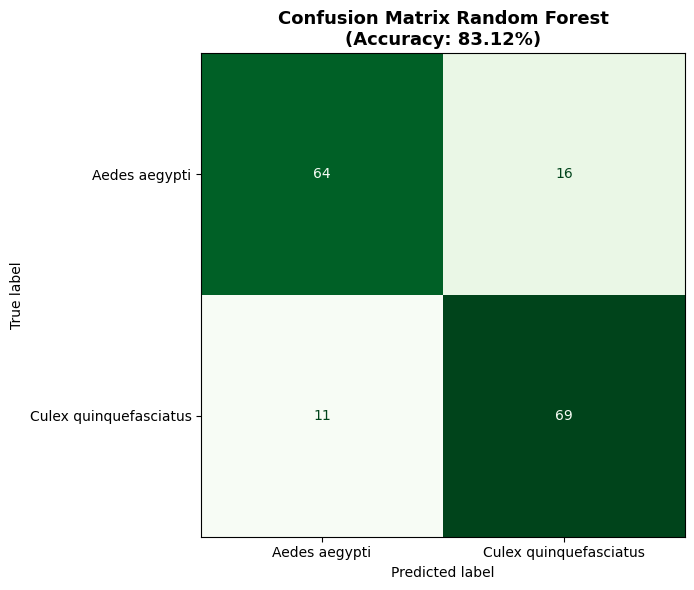

In [ ]:
#confusion matrix
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=le.classes_)
disp.plot(ax=ax, cmap='Greens', colorbar=False)
ax.set_title(f'Confusion Matrix Random Forest\n(Accuracy: {acc_rf*100:.2f}%)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

Model Random Forest menghasilkan akurasi 83,13% dengan precision 0,83, recall 0,83, dan F1-score 0,83 yang cukup seimbang di kedua kelas. Dari 80 citra Aedes, 16 sampel salah diklasifikasikan dan 11 dari 80 citra Culex ikut salah, lebih banyak dibanding SVM namun sebanding dengan KNN K=19. Hal ini menunjukkan Random Forest mampu menangkap pola tekstur GLCM dengan cukup baik meskipun belum seoptimal SVM.

# Evaluasi

In [ ]:
results = {
    'Model': ['KNN (Best)', 'KNN k=19', 'SVM', 'Random Forest'],
    'Best Params': [str(knn_grid.best_params_), f"k=19, metric={knn_grid.best_params_['metric']}, weights={knn_grid.best_params_['weights']}", str(svm_grid.best_params_), str(rf_grid.best_params_)],
    'CV Score': [knn_grid.best_score_, None, svm_grid.best_score_, rf_grid.best_score_],
    'Accuracy': [acc_knn, acc_knn19, acc_svm, acc_rf],
    'Precision': [prec_knn, prec_knn19, prec_svm, prec_rf],
    'Recall': [rec_knn, rec_knn19, rec_svm, rec_rf],
    'F1-Score': [f1_knn, f1_knn19, f1_svm, f1_rf]
} #tabel ringkasan semua metrik

df_results = pd.DataFrame(results)
print(df_results[['Model', 'CV Score', 'Accuracy', 'Precision', 'Recall', 'F1-Score']].to_string(index=False))

        Model  CV Score  Accuracy  Precision  Recall  F1-Score
   KNN (Best)  0.809961   0.82500   0.842330 0.82500  0.822757
     KNN k=19       NaN   0.83125   0.843320 0.83125  0.829754
          SVM  0.865234   0.90625   0.907843 0.90625  0.906158
Random Forest  0.806836   0.83125   0.832549 0.83125  0.831085


Hasilnya SVM konsisten unggul di semua metrik dibanding KNN dan Random Forest dengan CV Score 0,86523 dan akurasi 90,62%.

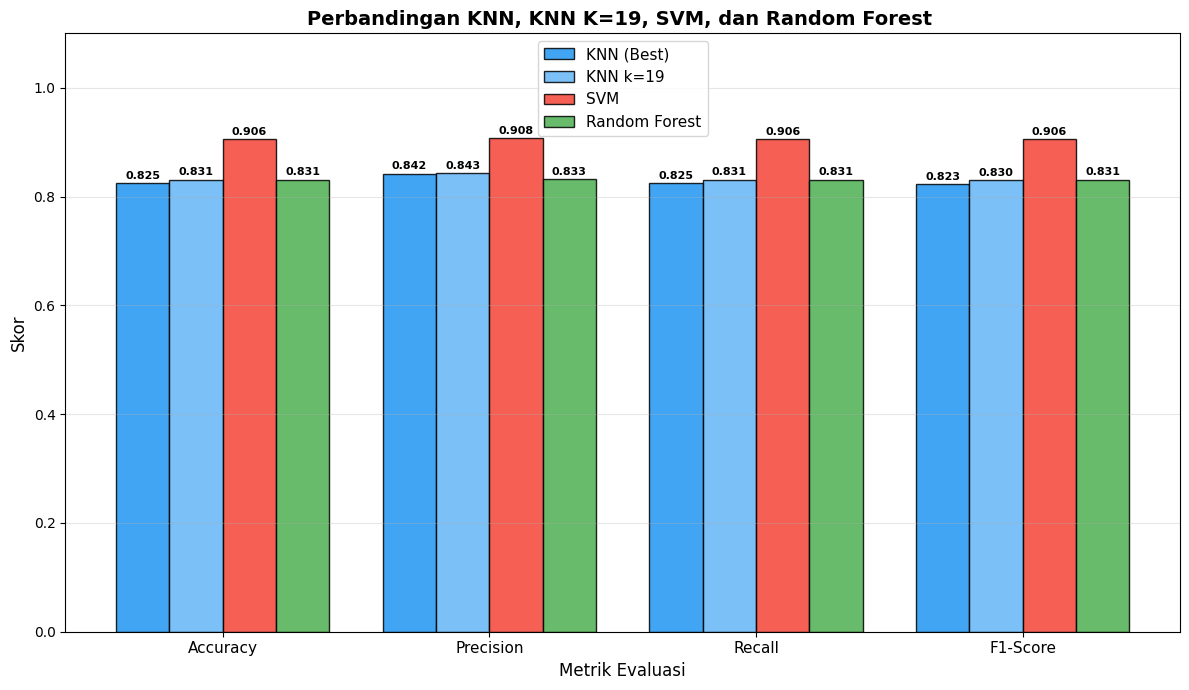

In [ ]:
#barchart perbandingan metrik knn, svm, random forest
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
knn_scores = [acc_knn, prec_knn, rec_knn, f1_knn]
knn19_scores = [acc_knn19, prec_knn19, rec_knn19, f1_knn19]
svm_scores = [acc_svm, prec_svm, rec_svm, f1_svm]
rf_scores = [acc_rf, prec_rf, rec_rf, f1_rf]

x = np.arange(len(metrics))
width = 0.2
fig, ax = plt.subplots(figsize=(12, 7))
bars1 = ax.bar(x - 1.5*width, knn_scores, width, label='KNN (Best)', color='#2196F3', alpha=0.85, edgecolor='black')
bars2 = ax.bar(x - 0.5*width, knn19_scores, width, label='KNN k=19', color='#64B5F6', alpha=0.85, edgecolor='black')
bars3 = ax.bar(x + 0.5*width, svm_scores, width, label='SVM', color='#F44336', alpha=0.85, edgecolor='black')
bars4 = ax.bar(x + 1.5*width, rf_scores, width, label='Random Forest', color='#4CAF50', alpha=0.85, edgecolor='black')

#nilai di atas bar
for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004, f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xlabel('Metrik Evaluasi', fontsize=12)
ax.set_ylabel('Skor', fontsize=12)
ax.set_title('Perbandingan KNN, KNN K=19, SVM, dan Random Forest ', fontweight='bold', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

SVM secara konsisten mengungguli model lain di semua metrik dengan selisih yang cukup signifikan, sementara KNN Best, KNN K=19, dan Random Forest menunjukkan performa yang sangat berdekatan pada rentang 0,82–0,84.

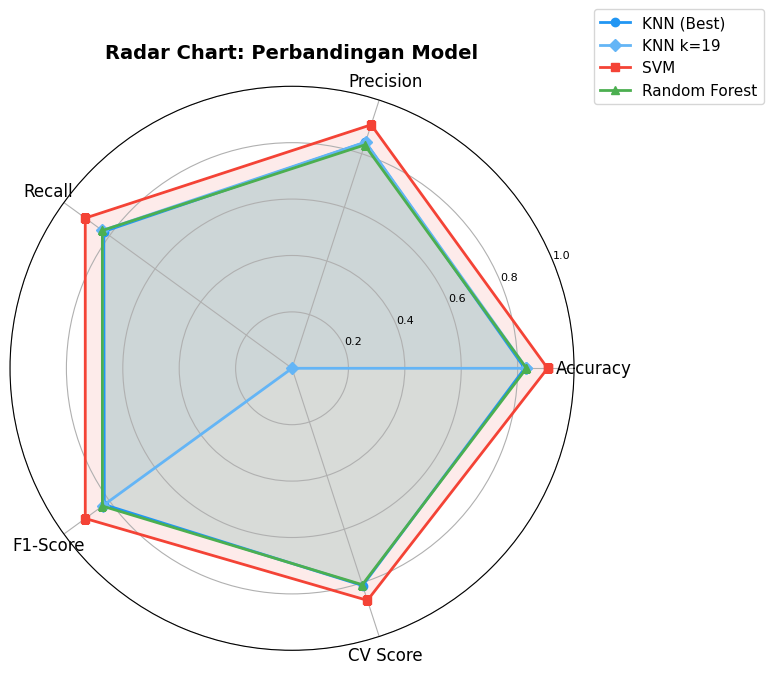

In [ ]:
#radar chart perbandingan multidimensi knn, svm, dan random forest
categories = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'CV Score']
knn_vals = [acc_knn, prec_knn, rec_knn, f1_knn, knn_grid.best_score_]
knn19_vals = [acc_knn19, prec_knn19, rec_knn19, f1_knn19, 0]  #cv score tidak dihitung untuk k=19
svm_vals = [acc_svm, prec_svm, rec_svm, f1_svm, svm_grid.best_score_]
rf_vals = [acc_rf, prec_rf, rec_rf, f1_rf, rf_grid.best_score_]

N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles_r = angles + [angles[0]]

def close(vals): return vals + [vals[0]]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.plot(angles_r, close(knn_vals), 'o-', color='#2196F3', linewidth=2, label='KNN (Best)')
ax.fill(angles_r, close(knn_vals), alpha=0.1, color='#2196F3')
ax.plot(angles_r, close(knn19_vals), 'D-', color='#64B5F6', linewidth=2, label='KNN k=19')
ax.fill(angles_r, close(knn19_vals), alpha=0.1, color='#64B5F6')
ax.plot(angles_r, close(svm_vals), 's-', color='#F44336', linewidth=2, label='SVM')
ax.fill(angles_r, close(svm_vals), alpha=0.1, color='#F44336')
ax.plot(angles_r, close(rf_vals), '^-', color='#4CAF50', linewidth=2, label='Random Forest')
ax.fill(angles_r, close(rf_vals), alpha=0.1, color='#4CAF50')

ax.set_xticks(angles)
ax.set_xticklabels(categories, fontsize=12)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=8)
ax.set_title('Radar Chart: Perbandingan Model', fontweight='bold', fontsize=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=11)
plt.tight_layout()
plt.show()

Radar chart menampilkan perbandingan multidimensi yang mencakup 5 metrik sekaligus termasuk CV Score. Area SVM yang lebih luas dibanding KNN dan Random Forest mempertegas bahwa SVM lebih unggul secara menyeluruh, bukan hanya di satu metrik tertentu saja.

In [ ]:
#kesimpulan akhir
all_acc = {'KNN (Best)': acc_knn, 'KNN k=19': acc_knn19, 'SVM': acc_svm, 'Random Forest': acc_rf}
all_f1 = {'KNN (Best)': f1_knn,  'KNN k=19': f1_knn19, 'SVM': f1_svm, 'Random Forest': f1_rf}

winner_acc = max(all_acc, key=all_acc.get)
winner_f1 = max(all_f1, key=all_f1.get)

print(f"Model terbaik (Accuracy): {winner_acc} — {all_acc[winner_acc]*100:.2f}%")
print(f"Model terbaik (F1-Score): {winner_f1} — {all_f1[winner_f1]:.4f}")

Model terbaik (Accuracy): SVM — 90.62%
Model terbaik (F1-Score): SVM — 0.9062


SVM dengan kernel RBF menjadi model terbaik baik berdasarkan akurasi maupun F1-score. Keunggulan SVM disebabkan kemampuannya menemukan hyperplane optimal di ruang fitur berdimensi tinggi (48 fitur GLCM), yang membuatnya lebih efektif memisahkan dua kelas dibandingkan pendekatan berbasis kedekatan jarak pada KNN maupun ensemble decision tree pada Random Forest.